# Generate Performance Boxplots and Feature Importance Calculations from WandB Runs
This notebook is designed to analyze performance metrics and feature importance from WandB runs. It includes sections for importing libraries, fetching data, generating performance boxplots, and calculating feature importance.

This notebook is essentially a pared-down, cleaned-up version of `stability_and_performance_analysis.ipynb`.

## Import Required Libraries
Import necessary libraries such as `wandb`, `pandas`, `numpy`, `matplotlib`, and `seaborn`.

In [1]:
# Import Required Libraries
import logging
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import wandb

# Setup Logging and Configuration
logging.basicConfig(
    format="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,
)
logger = logging.getLogger(__name__)

## Setup Logging and Configuration
Set up logging and define configurations such as WandB project name, sweep ID, and directories for saving results.

In [2]:
# Define WandB project and sweep details
PROJECT_NAME = "millergw/prostate_met_status"

GROUP_IDs = [
    # "simulated_data_001", # DO NOT USE; we used the test data during training as an evaluation set
    "simulated_data_002", # (n_samples = 10k, 1 seed, continuous)
    "simulated_data_003", #(n_samples = 1k, 3 seeds, binary and continuous)
    "simulated_data_004", # (n_samples = 10k, 2 seeds, continuous)
    "simulated_data_005", # (n_samples = 10k, binary, 3 seeds)
             ]

# updated continuous correlation to covariance code (Sigma=R, no scaling by bernoulli assumption)
SWEEP_IDs = [
    "r09um8op", # (n_samples = 10k, continuous, 3 seeds)
    "ftb6gc6n", # (n_samples = 1k, continuous, 3 seeds)
    "4h5ez29w", # (n_samples = 10k, binary, 3 seeds)
    "fxmjq8aq", # (n_samples = 1k, binary, 3 seeds)
    "y4gam7wy", # 7 more seeds, n=10k
    "4aawgqfu", # 7 more seeds, n=1k
]

# # Define directories for saving results
FIGDIR = f"../figures/joint_simulation_results/"
RESULTS_DIR = f"../results/joint_simulation_results/"
# make directory if it doesn't exist
os.makedirs(os.path.join(FIGDIR), exist_ok=True)

# Figure parameters
figsize_tuple = (2.4, 2.1)
aspect_ratio_value = 0.5
cmap_style = "viridis"

## Fetch WandB Runs and Performance Metrics (grouped by model_type, OR, and sigma)
Use the WandB API to fetch runs and extract performance metrics grouped by `model_type`, `odds_ratio`, `sigma`, and `n_samples` for purposes of assessing the 'power curve' of the model. Store the results in a DataFrame.

In [8]:
# Initialize W&B API
api = wandb.Api()
# Collect runs from both sweeps
all_records = []
# for group_id in GROUP_IDs: 
#     runs = api.runs(f"{PROJECT_NAME}", filters={"group": group_id, "state": "finished"})

for sweep_id in SWEEP_IDs:
    runs = api.runs(f"{PROJECT_NAME}", filters={"sweep": sweep_id, "state": "finished"})

    for run in runs: 
        config = run.config
        summary = run.summary
        all_records.append({
            "run_id": run.id,
            "run_name": run.name,
            "model_type": config.get("model_type"),
            "sample_binary": config.get("sample_binary"),
            "n_samples": config.get("num_samples"),
            "datasets": config.get("datasets"),
            "sigma": float(config.get("sigma")),
            "odds_ratio": float(config.get("odds_ratio")),
            "save_dir": config.get("save_dir"),
            "num_class1_samples": config.get("num_class1_samples"),
            "num_class0_samples": config.get("num_class0_samples"),
            "deltaMuGenes": config.get("deltaMuGenes"),
            "mod0_genes": config.get("mod0_genes"),
            "mod1_genes": config.get("mod1_genes"),
        })
        for split in ["train", "validation", "test"]:
            all_records[-1][f"{split}_roc_auc_score"] = summary.get(f"{split}_roc_auc_score")
            all_records[-1][f"{split}_balanced_acc"] = summary.get(f"{split}_balanced_acc")
            all_records[-1][f"{split}_avg_precision"] = summary.get(f"{split}_average_precision_score")
        for split in ["validation", "test"]:
            all_records[-1][f"{split}_feature_importances_path"] = os.path.join(config.get("save_dir"), f"{split}_gene_feature_importances.csv")
            all_records[-1][f"{split}_gene_importances_path"] = os.path.join(config.get("save_dir"), f"{split}_gene_importances.csv")

# Convert to a single DataFrame
df = pd.DataFrame(all_records)

# Add a counts column for each group
group_cols = ["model_type", "n_samples", "odds_ratio", "sigma", "sample_binary"]
df_counts = df.groupby(group_cols).size().reset_index(name="count")

# filter to only model_type == "pnet"
df = df[df["model_type"] == "pnet"].reset_index(drop=True)

# in "save_dir" column, replace "../../results/" with "/mnt/disks/gmiller_data1/pnet/results"
df["save_dir"] = df["save_dir"].str.replace("../../results/", "/mnt/disks/gmiller_data1/pnet/results/", regex=False)

# Add a unique group identifer column by joining together the unique identifiers: ["model_type", "n_features", "odds_ratio", "control_frequency", "sample_binary"]
df["group_identifier"] = df.apply(
    lambda row: f"OR-{row['odds_ratio']}_sigma-{row['sigma']}_nSamples-{row['n_samples']}_sampleBinary-{row['sample_binary']}",
    axis=1)

# Create df_avg by averaging over runs with the same group identifiers
df_avg = df.groupby(group_cols, as_index=False).mean()
df_avg = df_avg.merge(df_counts, on=group_cols)

# Create df_stdev by calculating the standard deviation over runs with the same group identifiers
df_stdev = df.groupby(group_cols, as_index=False).std()
df_stdev = df_stdev.merge(df_counts, on=group_cols)

In [4]:
df.shape

(640, 28)

In [5]:
df_avg

,model_type,n_samples,odds_ratio,sigma,sample_binary,num_class1_samples,num_class0_samples,train_roc_auc_score,train_balanced_acc,train_avg_precision,validation_roc_auc_score,validation_balanced_acc,validation_avg_precision,test_roc_auc_score,test_balanced_acc,test_avg_precision,count
0,pnet,1000,1.0,0.0,False,500.0,500.0,0.502318,0.498429,0.512667,0.501227,0.504000,0.513629,0.499964,0.502667,0.514971,10
1,pnet,1000,1.0,0.0,True,500.0,500.0,0.579639,0.539571,0.569085,0.562320,0.523333,0.562952,0.512951,0.496667,0.520938,10
2,pnet,1000,1.0,0.1,False,500.0,500.0,0.539947,0.525143,0.538945,0.517982,0.510667,0.543691,0.489787,0.487333,0.512295,10
3,pnet,1000,1.0,0.1,True,500.0,500.0,0.564671,0.533429,0.563139,0.520098,0.517333,0.535130,0.509476,0.485333,0.516080,10
4,pnet,1000,1.0,0.5,False,500.0,500.0,0.522157,0.516143,0.521422,0.546187,0.506000,0.553512,0.497707,0.502000,0.505052,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,pnet,10000,10.0,0.1,True,5000.0,5000.0,0.997824,0.978971,0.998004,0.997609,0.978067,0.997853,0.997839,0.978667,0.997995,10
60,pnet,10000,10.0,0.5,False,5000.0,5000.0,0.891620,0.805314,0.899356,0.879580,0.795867,0.885078,0.885440,0.798867,0.893744,10
61,pnet,10000,10.0,0.5,True,5000.0,5000.0,0.994653,0.965171,0.995232,0.994453,0.965867,0.995033,0.994233,0.962600,0.994887,10
62,pnet,10000,10.0,0.8,False,5000.0,5000.0,0.924387,0.842329,0.924306,0.923042,0.837200,0.924302,0.920999,0.836133,0.921111,10


## helper functions

In [6]:
def smart_ticklabels(labels):
    return [f"{int(l)}" if float(l).is_integer() else f"{l:.1f}" for l in labels]

def get_smart_odds_ratio_labels(axessubplot_object):
    """Expects type <class 'matplotlib.axes._subplots.AxesSubplot'> as input"""
    smart_yticks = smart_ticklabels([float(l.get_text()) for l in axessubplot_object.get_yticklabels()])
    return smart_yticks


## 3 different results/subresults
Here we make performance heatmaps for three different subsets of the data:

- (A) sample_binary = True, n_samples=1000
- (B) sample_binary = False, n_samples=1000
- (C) sample_binary = False, n_samples=10000

Plot these side-by-side in one figure: "Mean Average Precision under varied joint sampling strategies"

In [7]:
# # each plotted as separate heatmap
# def heatmap_no_counts(df, title):
#     precision = df.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision")
#     # plt.figure(figsize=figsize_tuple)
#     fig, ax = plt.subplots(figsize=figsize_tuple)
#     sns.heatmap(precision, cmap=cmap_style, annot=True, fmt=".2f", cbar=False)
#     ax.set_aspect(aspect_ratio_value, adjustable='box')
#     ax.set_yticklabels(get_smart_odds_ratio_labels(ax))

#     plt.title(title)
#     plt.xlabel("sigma")
#     plt.ylabel("odds_ratio")
#     plt.tight_layout()
#     plt.show()

# eval_set = "test"
# heatmap_no_counts(
#     df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 1000)],
#     f"Binary, N=1k ({eval_set} set)"
# )

# heatmap_no_counts(
#     df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 1000)],
#     f"Continuous, N=1k ({eval_set} set)"
# )

# heatmap_no_counts(
#     df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 10000)],
#     f"Binary, N=10k ({eval_set} set)"
# )

# heatmap_no_counts(
#     df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 10000)],
#     f"Continuous, N=10k ({eval_set} set)"
# )

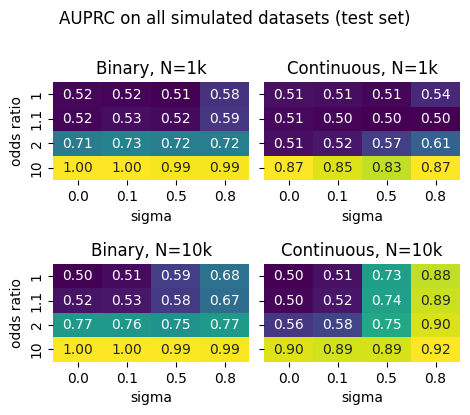

In [12]:
# current best: one 2x2 heatmap
def heatmap_no_counts(df, title, ax):
    precision = df.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision")
    sns.heatmap(
        precision, cmap=cmap_style, annot=True, fmt=".2f",
        cbar=False, ax=ax
    )
    ax.set_aspect(aspect_ratio_value, adjustable='box')
    ax.set_yticklabels(get_smart_odds_ratio_labels(ax))
    ax.set_title(title)
    ax.set_xlabel("sigma")
    ax.set_ylabel("odds ratio")

eval_set = "test"
fig, axes = plt.subplots(2, 2, figsize=(figsize_tuple[0]*2, figsize_tuple[1]*2))

# Row 0: N = 1k
heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 1000)],
    "Binary, N=1k",
    ax=axes[0, 0]
)

heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 1000)],
    "Continuous, N=1k",
    ax=axes[0, 1]
)

# Row 1: N = 10k
heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == True) & (df_avg["n_samples"] == 10000)],
    "Binary, N=10k",
    ax=axes[1, 0]
)

heatmap_no_counts(
    df_avg[(df_avg["sample_binary"] == False) & (df_avg["n_samples"] == 10000)],
    "Continuous, N=10k",
    ax=axes[1, 1]
)
axes[0,1].set_ylabel("")
axes[1,1].set_ylabel("")
axes[0,1].set_yticklabels("")
axes[1,1].set_yticklabels("")

fig.suptitle(f"AUPRC on all simulated datasets ({eval_set} set)")
plt.tight_layout()
plt.show()


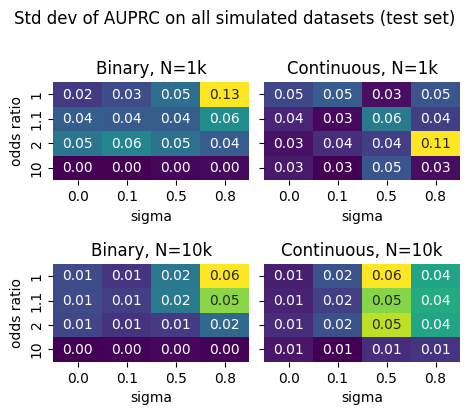

In [14]:
# current best: one 2x2 heatmap
def heatmap_no_counts(df, title, ax):
    precision = df.pivot(index="odds_ratio", columns="sigma", values=f"{eval_set}_avg_precision")
    sns.heatmap(
        precision, cmap=cmap_style, annot=True, fmt=".2f",
        cbar=False, ax=ax
    )
    ax.set_aspect(aspect_ratio_value, adjustable='box')
    ax.set_yticklabels(get_smart_odds_ratio_labels(ax))
    ax.set_title(title)
    ax.set_xlabel("sigma")
    ax.set_ylabel("odds ratio")

eval_set = "test"
fig, axes = plt.subplots(2, 2, figsize=(figsize_tuple[0]*2, figsize_tuple[1]*2))

# Row 0: N = 1k
heatmap_no_counts(
    df_stdev[(df_stdev["sample_binary"] == True) & (df_stdev["n_samples"] == 1000)],
    "Binary, N=1k",
    ax=axes[0, 0]
)

heatmap_no_counts(
    df_stdev[(df_stdev["sample_binary"] == False) & (df_stdev["n_samples"] == 1000)],
    "Continuous, N=1k",
    ax=axes[0, 1]
)

# Row 1: N = 10k
heatmap_no_counts(
    df_stdev[(df_stdev["sample_binary"] == True) & (df_stdev["n_samples"] == 10000)],
    "Binary, N=10k",
    ax=axes[1, 0]
)

heatmap_no_counts(
    df_stdev[(df_stdev["sample_binary"] == False) & (df_stdev["n_samples"] == 10000)],
    "Continuous, N=10k",
    ax=axes[1, 1]
)
axes[0,1].set_ylabel("")
axes[1,1].set_ylabel("")
axes[0,1].set_yticklabels("")
axes[1,1].set_yticklabels("")

fig.suptitle(f"Std dev of AUPRC on all simulated datasets ({eval_set} set)")
plt.tight_layout()
plt.show()


## scratch: WIP get feat imps

Goal: heatmap-style plot with the mean/median rank (importance) of the:

- deltaMu genes
- genes only in corr module
- genes in both corr module that also have deltaMu

In [14]:
########## Functions to extract gene imp and rank ##########
def load_feature_importances(importances_path):
    """
    Load feature importance data from a CSV file.

    Args:
        importances_path (str): Path to the feature importance file.

    Returns:
        pd.DataFrame: DataFrame of feature importances.
    """
    if not os.path.exists(importances_path):
        raise FileNotFoundError(f"File not found: {importances_path}")
    logger.debug(f"Loading feature importances from {importances_path}")
    imps = pd.read_csv(importances_path).set_index('Unnamed: 0')
    logger.debug(f"Loaded imps with shape {imps.shape}")
    return imps


def process_importances(imps, response_df):
    """
    Process feature importances by joining with response data and calculating differences between sample classes.
    This function computes the mean feature importances for each response class and then calculates the difference between them.
    The result is a Series of feature importance differences.

    Args:
        imps (pd.DataFrame): Feature importance DataFrame.
        response_df (pd.DataFrame): Response variable DataFrame.

    Returns:
        pd.Series: Processed feature importance differences.
    """
    logger.debug(f"head of imps.join(response_df).groupby('response').mean(): {imps.join(response_df).groupby('response').mean().head()}")
    logger.debug(f"shape of imps.join(response_df).groupby('response').mean(): {imps.join(response_df).groupby('response').mean().shape}")
    return imps.join(response_df).groupby('response').mean().diff(axis=0).iloc[1]


def build_runwise_gene_importance_rank_df(df, importance_path_column='gene_importances_path'):
    """
    Build a DataFrame summarizing gene importance and rank for each run and gene set.

    For each run in df, this function:
      - Loads the gene importances and computes the class-difference importance vector.
      - Computes the absolute rank of each gene (lower rank = more important).
      - Restricts to genes in each of three sets: "deltaMuGenes", "mod1_genes", "mod0_genes".
      - For each gene in each set, records the run ID, gene set, gene name, mean rank, and mean importance.

    Args:
        df (pd.DataFrame): DataFrame with one row per run, containing columns for run_id, gene sets, and path to gene importances.
        response_df (pd.DataFrame): DataFrame with sample responses, indexed by sample name, with column 'response'.
        importance_path_column (str): Column name in df with the path to the gene importances CSV.

    Returns:
        pd.DataFrame: DataFrame with columns [run_id, gene_perturbation_group, gene, rank, imp], where rank and imp are the mean rank and mean importance for each gene in each run and gene set.
    """
    logger.info(f"For each of the {df.shape[0]} model runs, we are getting gene importance and rank for each gene set")
    records = []
    for idx, row in df.iterrows():
        # Use index as run_id if no explicit run_id column
        run_id = row.get("run_id") or row.get("wandb_run_id") or idx
        logger.debug(f"Processing run {run_id} with row: {row.to_dict()}")

        logger.debug("Parse gene sets")
        deltaMuGenes = set(row["deltaMuGenes"])
        mod1_genes = set(row["mod1_genes"])
        mod0_genes = set(row["mod0_genes"])
        gene_perturbation_groups = {
            "deltaMuGenes": deltaMuGenes,
            "mod1_genes": mod1_genes,
            "mod0_genes": mod0_genes,
        }
        logger.debug(f"genes in both deltaMuGenes and mod1_genes: {deltaMuGenes.intersection(mod1_genes)}")

        logger.debug(f"Construct response_df from the number of samples, knowing that we had even split (first half are class 1)")
        n1 = row.get("num_class1_samples")
        n0 = row.get("num_class0_samples")
        response_df = np.concatenate([np.ones(n1), np.zeros(n0)])
        response_df = pd.DataFrame(response_df.astype(int), index=[f"Sample_{i}" for i in range(n1+n0)], columns=["response"])
        logger.debug(f"constructed response_df with shape {response_df.shape}")

        try:
            logger.debug("Loading importances")
            imps = load_feature_importances(row[importance_path_column])
            logger.debug("Processing importances")
            processed_imps = process_importances(imps, response_df)
            # processed_imps: pd.Series, index=gene names
            logger.debug("Ranks are calculated from the absolute(importance)")
            ranks = processed_imps.abs().rank(ascending=False)
        except Exception as e:
            logger.warning(f"Skipping run {run_id} due to error: {e}. \nCheck: does a file exist at {row[importance_path_column]}?")
            continue        

        logger.debug("For each gene set, collect mean importance and rank for each gene")
        for gene_perturbation_group_name, gene_perturbation_group in gene_perturbation_groups.items():
            for gene in gene_perturbation_group:
                if gene in processed_imps.index and gene in ranks.index:
                    records.append({
                        "run_id": run_id,
                        "gene_perturbation_group": gene_perturbation_group_name,
                        "gene": gene,
                        "rank": ranks[gene],
                        "imp": processed_imps[gene],                        
                    })

    final_df = pd.DataFrame(records)
    return final_df


########## Functions to plot top-k recovery ##########
def filter_runs(df, sample_binary=False, n_samples=10000, model_type="pnet"):
    """Filter runs for a given sample_binary, n_samples, and model_type."""
    return df[
        (df["sample_binary"] == sample_binary) &
        (df["n_samples"] == n_samples) &
        (df["model_type"] == model_type)
    ].copy()

def get_group_identifier(row):
    """Create a group identifier string for a run."""
    return f"OR-{row['odds_ratio']}_sigma-{row['sigma']}_nSamples-{row['n_samples']}_sampleBinary-{row['sample_binary']}"

def assign_group_identifier(df):
    """Assign group_identifier column to a DataFrame."""
    df = df.copy()
    df["group_identifier"] = df.apply(get_group_identifier, axis=1)
    return df

def get_gene_sets(row):
    """Return dict of gene sets for a run."""
    delta = set(row["deltaMuGenes"])
    mod0 = set(row["mod0_genes"])
    mod1 = set(row["mod1_genes"])
    corr = mod0 | mod1 # set union
    only_linear = delta - corr
    only_nonlinear = corr - delta
    both = delta & corr
    return {
        "only linear": only_linear,
        "only nonlinear": only_nonlinear,
        "both": both
    }

def add_gene_set_column(per_run_imps_df, df):
    """Add a 'gene_set_type' column to per_run_imps_df: only linear, only nonlinear, both."""
    # Build a mapping from run_id to gene sets
    runid_to_sets = {}
    for _, row in df.iterrows():
        runid_to_sets[row["run_id"]] = get_gene_sets(row)
    # Assign gene_set_type for each row in per_run_imps_df
    def which_set(row):
        sets = runid_to_sets.get(row["run_id"], {})
        for set_name, genes in sets.items():
            if row["gene"] in genes:
                return set_name
        return None
    per_run_imps_df = per_run_imps_df.copy()
    per_run_imps_df["gene_set_type"] = per_run_imps_df.apply(which_set, axis=1)
    return per_run_imps_df

def aggregate_heatmap(per_run_imps_df, df, value_col, gene_set_type):
    """
    Aggregate median value_col (rank or imp) for each group_identifier, odds_ratio, sigma, and gene_set_type.
    Returns a DataFrame with odds_ratio as rows, sigma as columns.
    """
    # Merge group_identifier and odds_ratio/sigma into per_run_imps_df
    meta = df[["run_id", "group_identifier", "odds_ratio", "sigma"]]
    merged = per_run_imps_df.merge(meta, on="run_id")
    # Filter for the gene_set_type
    merged = merged[merged["gene_set_type"] == gene_set_type]
    # Group by group_identifier, odds_ratio, sigma, then aggregate median across genes and runs
    agg = merged.groupby(["odds_ratio", "sigma"])[value_col].median().unstack()
    return agg


def aggregate_topk_recovery(per_run_imps_df, df, gene_set_type):
    """
    For each run, compute the fraction of signal genes (of this gene_set_type) recovered in the top K genes,
    where K = total number of signal genes for that run (across all three sets).
    Returns a DataFrame with odds_ratio as rows, sigma as columns, values are median top-K recovery across runs.
    """
    # Merge group_identifier and odds_ratio/sigma into per_run_imps_df
    meta = df[["run_id", "group_identifier", "odds_ratio", "sigma", "deltaMuGenes", "mod0_genes", "mod1_genes"]]
    merged = per_run_imps_df.merge(meta, on="run_id")
    records = []
    for run_id, group in merged.groupby("run_id"):
        # Get all signal genes for this run
        row = group.iloc[0]
        delta = set(row["deltaMuGenes"])
        mod0 = set(row["mod0_genes"])
        mod1 = set(row["mod1_genes"])
        only_linear = delta - (mod0 | mod1)
        only_nonlinear = (mod0 | mod1) - delta
        both = delta & (mod0 | mod1)
        all_signal_genes = only_linear | only_nonlinear | both
        K = len(all_signal_genes)
        if K == 0:
            continue
        # Get the genes of the current gene_set_type for this run
        if gene_set_type == "only linear":
            signal_genes = only_linear
        elif gene_set_type == "only nonlinear":
            signal_genes = only_nonlinear
        elif gene_set_type == "both":
            signal_genes = both
        else:
            continue
        if len(signal_genes) == 0:
            continue
        # Get all genes and their ranks for this run
        run_genes = group[["gene", "rank"]].drop_duplicates().set_index("gene")["rank"]
        # For each gene in the set, check if its rank <= K
        n_in_topk = sum(run_genes.get(gene, K+1) <= K for gene in signal_genes)
        # Compute recovery: fraction of signal genes in top K
        recovery = n_in_topk / len(signal_genes)
        records.append({
            "run_id": run_id,
            "gene_set_type": gene_set_type,
            "odds_ratio": row["odds_ratio"],
            "sigma": row["sigma"],
            "topk_recovery": recovery
        })
    # Aggregate by odds_ratio, sigma (median across runs)
    df = pd.DataFrame(records)
    heatmap_df = df.groupby(["odds_ratio", "sigma"])["topk_recovery"].median().unstack()
    stdev_df = df.groupby(["odds_ratio", "sigma"])["topk_recovery"].std().unstack()
    return heatmap_df, stdev_df, df

## Get run-level rank and importance information for all the relevant gene sets
Each row in df_feature_importance_paths corresponds to a run. I would like my final output to be a DF with columns [run_id, gene_set, gene, rank, imp]. The run_id is the identifer for a given run (wandb run id). The gene set is one of "deltaMuGenes", "mod1_genes", "mod0_genes". The rank is the mean rank of the gene across all samples in that run. The imp is the mean importance of the gene across all samples in that run.

In [15]:
logger.setLevel(logging.INFO)

In [16]:
eval_set = "test"
per_run_imps_df = build_runwise_gene_importance_rank_df(df, importance_path_column=f'{eval_set}_gene_importances_path')
per_run_imps_df

2025-09-02 21:54:31 INFO     [__main__] For each of the 640 model runs, we are getting gene importance and rank for each gene set


,run_id,gene_perturbation_group,gene,rank,imp
0,cta6s1bg,deltaMuGenes,TBCK,52.0,-0.000245
1,cta6s1bg,deltaMuGenes,DPY19L4,51.0,0.000256
2,cta6s1bg,deltaMuGenes,RGS21,21.0,0.000744
3,cta6s1bg,deltaMuGenes,TRPM8,31.0,-0.000515
4,cta6s1bg,deltaMuGenes,ADD1,80.0,-0.000058
...,...,...,...,...,...
38395,zlzh83ag,mod0_genes,SATB2,62.0,-0.005735
38396,zlzh83ag,mod0_genes,TOP2B,61.0,0.006372
38397,zlzh83ag,mod0_genes,TESK1,46.0,0.010536
38398,zlzh83ag,mod0_genes,ARMC9,20.0,0.041642


## Build heatmap of top-k recovery
switch metric to top-k recovery/top-k accuracy (not median rank). "How many of the true signal genes did my model recover among the top K?"
Also possible to use recall at K (same as accuracy but plotted as a curve for varied K) or Precision at K ("how 'pure' is my top K list?)

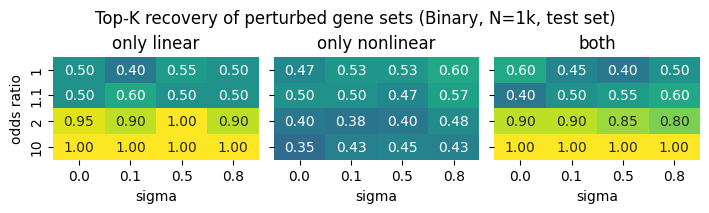

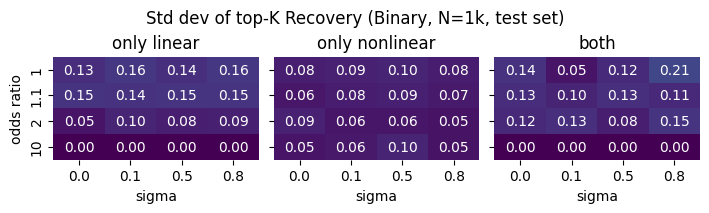

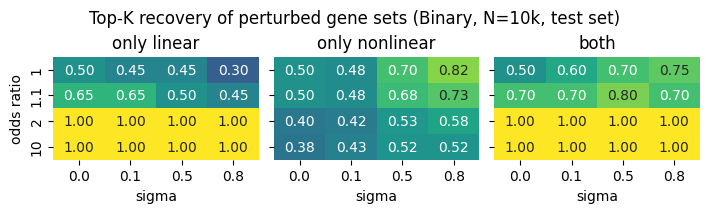

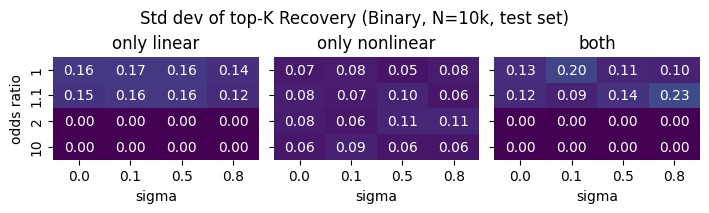

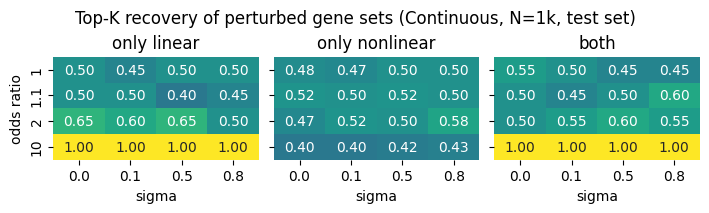

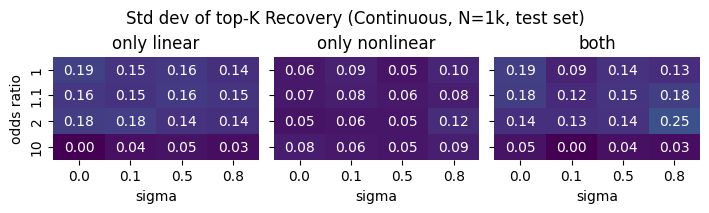

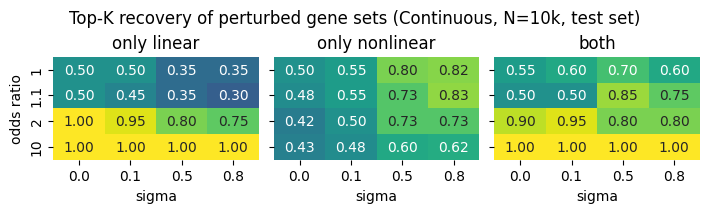

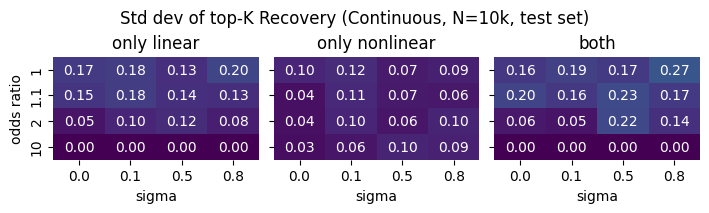

In [17]:
# --- MAIN LOGIC ---

# 1. Filter runs and per_run_imps_df
# df_filt = filter_runs(df, sample_binary=False, n_samples=10000) # continuous 10k

df_filts = {
    "Binary, N=1k": filter_runs(df, sample_binary=True, n_samples=1000),
    "Binary, N=10k": filter_runs(df, sample_binary=True, n_samples=10000),
    "Continuous, N=1k": filter_runs(df, sample_binary=False, n_samples=1000),
    "Continuous, N=10k": filter_runs(df, sample_binary=False, n_samples=10000),
    
}

for df_filt_name, df_filt in df_filts.items():
    if df_filt.shape[0] == 0:
        logger.info(f"{df_filt_name} had nothing left in the filtered runs")
        continue # skip this figure
    run_ids = set(df_filt["run_id"])
    per_run_filt = per_run_imps_df[per_run_imps_df["run_id"].isin(run_ids)].copy()

    # 2. Assign group_identifier to both DFs
    df_filt = assign_group_identifier(df_filt)

    # 3. Add gene_set_type column to per_run_filt
    per_run_filt = add_gene_set_column(per_run_filt, df_filt)
    # drop duplicates in per_run_filt based on run_id, gene, and gene_set_type, because only want to count each gene once per run (even if it occurs in multiple gene set categories)
    per_run_filt = per_run_filt.drop_duplicates(subset=["run_id", "gene", "gene_set_type"])

    # 4. Aggregate for each gene set and value type (recovery heatmap)
    fig, axes = plt.subplots(1, 3, figsize=(figsize_tuple[0]*3, figsize_tuple[1]), sharey=True)
    for col_idx, gene_set in enumerate(["only linear", "only nonlinear", "both"]):
        heatmap_df, _, _ = aggregate_topk_recovery(per_run_filt, df_filt, gene_set)
        ax = axes[col_idx]
        sns.heatmap(heatmap_df, annot=True, cmap=cmap_style, ax=ax, fmt=".2f", vmin=0, vmax=1, cbar=False)
        # ax.set_title(f"Top-K Recovery: {gene_set} ({eval_set} set)")
        ax.set_aspect(aspect_ratio_value)
        ax.set_title(f"{gene_set}")
        ax.set_xlabel("sigma")
        if col_idx == 0:
            ax.set_ylabel("odds ratio")
        else:
            ax.set_ylabel("")
    axes[0].set_yticklabels(get_smart_odds_ratio_labels(axes[0]))
    plt.tight_layout()
    plt.suptitle(f"Top-K recovery of perturbed gene sets ({df_filt_name}, {eval_set} set)")
    plt.show()

    # 5. Std dev heatmap
    fig, axes = plt.subplots(1, 3, figsize=(figsize_tuple[0]*3, figsize_tuple[1]), sharey=True)
    for col_idx, gene_set in enumerate(["only linear", "only nonlinear", "both"]):
        _, stdev_df, _ = aggregate_topk_recovery(per_run_filt, df_filt, gene_set)
        ax = axes[col_idx]
        sns.heatmap(stdev_df, annot=True, cmap=cmap_style, ax=ax, fmt=".2f", vmin=0, vmax=1, cbar=False)
        ax.set_aspect(aspect_ratio_value)
        ax.set_title(f"{gene_set}")
        ax.set_xlabel("sigma")
        if col_idx == 0:
            ax.set_ylabel("odds ratio")
        else:
            ax.set_ylabel("")
    axes[0].set_yticklabels(get_smart_odds_ratio_labels(axes[0]))
    plt.tight_layout()
    plt.suptitle(f"Std dev of top-K Recovery ({df_filt_name}, {eval_set} set)")
    plt.show()

In [18]:
_, _, tmp1 = aggregate_topk_recovery(per_run_filt, df_filt, "both")
_, _, tmp2 = aggregate_topk_recovery(per_run_filt, df_filt, "only nonlinear")
_, _, tmp3 = aggregate_topk_recovery(per_run_filt, df_filt, "only linear")
df_topk = pd.concat([tmp1, tmp2, tmp3], ignore_index=True)
df_topk = df_topk[(df_topk["odds_ratio"] == 1.1) ]
df_topk

,run_id,gene_set_type,odds_ratio,sigma,topk_recovery
2,0kw78s7o,both,1.1,0.0,0.7
4,0y88e0zx,both,1.1,0.5,0.9
5,1p8dy6p5,both,1.1,0.1,0.5
11,2huydcal,both,1.1,0.1,0.4
12,2tjm7nqs,both,1.1,0.1,0.6
...,...,...,...,...,...
462,x1xv0pvj,only linear,1.1,0.8,0.4
463,x3g5jsct,only linear,1.1,0.1,0.4
468,yci3kgtc,only linear,1.1,0.0,0.5
474,z5fzc3ur,only linear,1.1,0.1,0.3


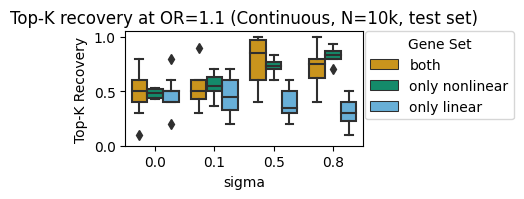

In [19]:


# 5. Plot
# color_mapping = {
#     "only linear": '#0173B2',
#     "only nonlinear":  '#029E73',
#     "both": '#E69F00',
# }
color_mapping = {
    "only linear": '#56B4E9',
    "only nonlinear":  '#009E73',
    "both": '#E69F00'#'#CC79A7',
}

# plt.figure(figsize=(7,4))
plt.figure(figsize=(figsize_tuple[0]*2, figsize_tuple[1]*1.))

sns.boxplot(
    data=df_topk,
    x="sigma",
    y="topk_recovery",
    hue="gene_set_type",
    showfliers=True,
    palette=color_mapping
)

# sns.stripplot(
#     data=df_topk,
#     x="sigma",
#     y="topk_recovery",
#     hue="gene_set_type",
#     dodge=True,
#     color="black",
#     alpha=0.25,
#     legend=False
# )

plt.ylim(0, 1.05)
plt.title(f"Top-K recovery at OR=1.1 ({df_filt_name}, {eval_set} set)")
plt.ylabel("Top-K Recovery")
plt.xlabel("sigma")
plt.legend(title="Gene Set", bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
# plt.legend(title="Gene Set", loc="best")
plt.tight_layout()
plt.show()


## Logic for generating feature importance and rank heatmaps

1. Filter the relevant runs
- Start by filtering df_feature_importance_paths for the subset you want (e.g., Continuous, N=10k).
- Make this filtering modular so you can easily swap to other subsets (e.g., N=1k).

2. Extract gene sets for each run
- For each row/run, parse the gene lists:
    - deltaMuGenes
    - mod0_genes and mod1_genes (combine for "corr module")
- Compute the three gene sets for each run:
    - deltaMuGenes
    - only in corr module (mod0+mod1 minus deltaMu)
    - intersection (deltaMu ∩ (mod0+mod1))

3. Aggregate gene ranks/importances

- For each run, use the corresponding group_identifier to get the gene importance/rank DataFrame from df_ranks_by_key (or df_imps_by_key).
- For each gene set, extract the ranks/importances for the genes in that set.
- Aggregate (e.g., median) across genes in the set, for each run.

4. Aggregate across runs with the same group_identifier
- For each group_identifier (i.e., each cell in the heatmap), aggregate the median ranks/importances across all runs with that group_identifier.

5. Build heatmap DataFrames
- For each gene set, build a DataFrame with odds_ratio as rows and sigma as columns, values are the top K recovery (alternatives: aggregated median ranks/importances.)

6. Plot heatmaps
- Use the same plotting style as elsewhere in the notebook.